In [ ]:
# Computer Vision: Transfer Learning & Model Interpretability

# Phase 1: Environment Setup & Hyperparameters
# In this section, we import the necessary libraries for deep learning, data visualization, and model interpretability. 
# We also define the global hyperparameters for image processing and training configurations.

In [4]:
# --- 1. Core Libraries & Environment Setup ---

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import seaborn as sns

import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.layers import Input, RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorboard import program
import datetime
import os
import subprocess
import webbrowser
import time


# --- 2. Global Hyperparameters Configuration ---
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 5 # Total number of classes in the tf_flowers dataset

In [ ]:
# Phase 2: Data Loading & Preprocessing Pipeline
# We load the `tf_flowers` dataset directly from TensorFlow Datasets, splitting it into training (80%) and validation (20%) sets. 
# We then build an optimized data pipeline utilizing caching, shuffling, and prefetching for maximum GPU throughput.

In [5]:
# --- 3. Image Preprocessing Function ---
def preprocess_image(image, label):
    # Resize images to a uniform 224x224 dimension
    image = tf.image.resize(image, IMG_SIZE)
    # Apply ResNetV2 specific pixel normalization
    image = tf.keras.applications.resnet_v2.preprocess_input(image)
    return image, label

print("Downloading and loading the tf_flowers dataset...")
# Load dataset with an 80/20 train-validation split
(train_raw, val_raw), ds_info = tfds.load(
    'tf_flowers',
    split=['train[:80%]', 'train[80%:]'],
    as_supervised=True,
    with_info=True
)

# --- 4. Data Pipeline Optimization ---
# Apply mapping, shuffling, batching, and autotune prefetching
train_ds = train_raw.map(preprocess_image).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_raw.map(preprocess_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
print("✅ Data pipeline successfully configured!")

Завантаження датасету tf_flowers...
Пайплайн даних успішно сформовано!


In [ ]:
# Phase 3: Exploratory Data Analysis (EDA)
# Before modeling, we analyze the dataset's class distribution to check for imbalances and visualize the original image dimensions. 
# We also display a grid of raw images to understand the visual complexity of the data.

Розвідувальний аналіз даних
Загальна кількість зображень: 3670
Класи: ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']
Аналізуємо розміри та класи (це займе кілька секунд)...


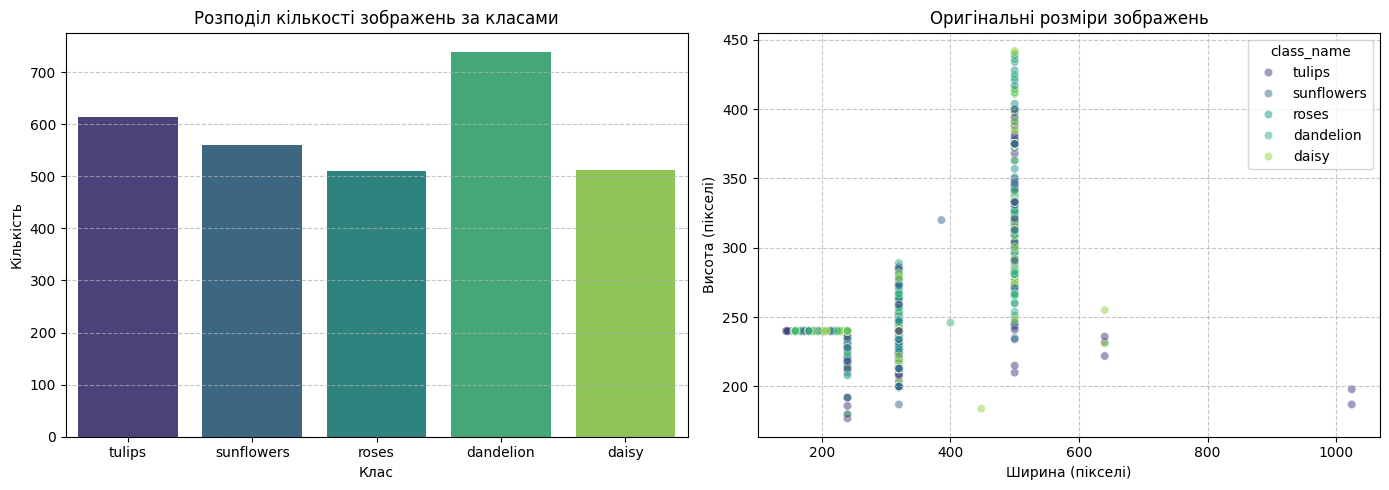

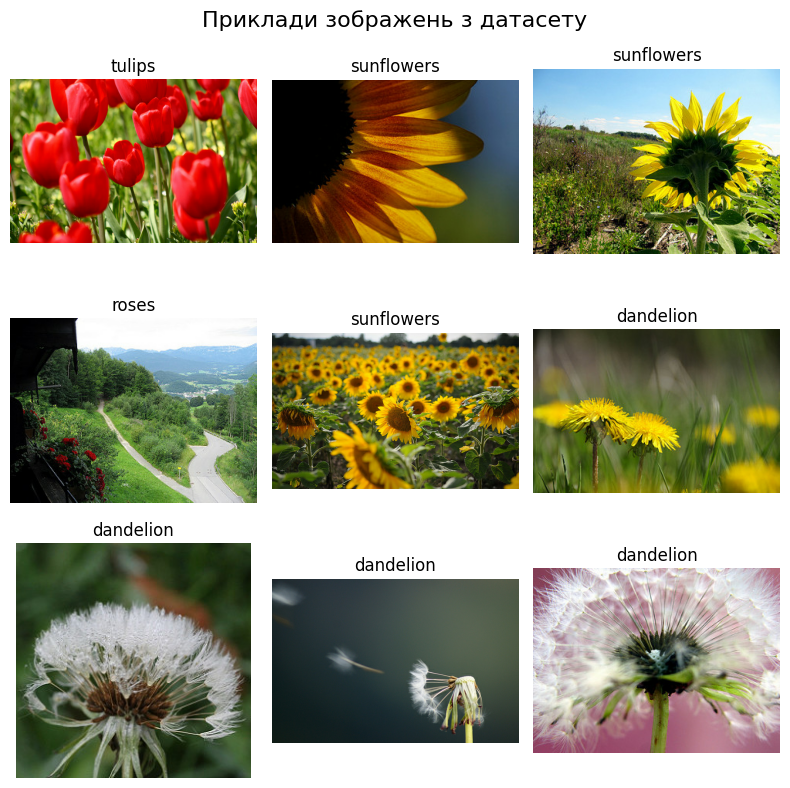

In [7]:
print("--- Initiating Exploratory Data Analysis ---")

# --- 1. Dataset Overview ---
total_examples = ds_info.splits['train'].num_examples
class_names = ds_info.features['label'].names
print(f"Total Images: {total_examples}")
print(f"Class Names: {class_names}")

# --- 2. Extracting Dimensions & Labels ---
print("Analyzing image dimensions and class distribution (this may take a moment)...")
labels, heights, widths = [], [], []

# Using train_raw to analyze original, uncropped dimensions
for img, label in train_raw:
    labels.append(label.numpy())
    heights.append(img.shape[0])
    widths.append(img.shape[1])

df_eda = pd.DataFrame({'label': labels, 'height': heights, 'width': widths})
df_eda['class_name'] = df_eda['label'].apply(lambda x: class_names[x])

# --- 3. EDA Visualizations ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Class Distribution (Checking for severe imbalance)
sns.countplot(data=df_eda, x='class_name', hue='class_name', palette='viridis', legend=False, ax=axes[0])
axes[0].set_title("Image Distribution per Class")
axes[0].set_xlabel("Class Name")
axes[0].set_ylabel("Count")
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot 2: Image Dimensions (Width vs. Height scatter)
sns.scatterplot(data=df_eda, x='width', y='height', hue='class_name', alpha=0.5, palette='viridis', ax=axes[1])
axes[1].set_title("Original Image Dimensions")
axes[1].set_xlabel("Width (pixels)")
axes[1].set_ylabel("Height (pixels)")
axes[1].grid(linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# --- 4. Raw Image Samples Grid ---
plt.figure(figsize=(8, 8))
for i, (image, label) in enumerate(train_raw.take(9)):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image.numpy())
    plt.title(class_names[label.numpy()])
    plt.axis("off")
plt.suptitle("Raw Dataset Image Samples", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# Phase 4: ResNet50V2 Transfer Learning (Feature Extraction)
# We leverage a pre-trained ResNet50V2 model acting as a feature extractor. During this phase, all base layers are frozen, and 
# only the newly added custom classification head is trained. We also integrate a dynamic data augmentation layer.

In [3]:
print("Constructing Model Architecture with Data Augmentation...")

# --- 1. Data Augmentation Block ---
# Active ONLY during the training phase
data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal_and_vertical"),
    RandomRotation(0.2),
    RandomZoom(0.2),
], name="Data_Augmentation")

# --- 2. Base Model Instantiation (ResNet50V2) ---
base_model = ResNet50V2(input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet')

# FREEZE all base model weights for the initial feature extraction phase
base_model.trainable = False

# --- 3. Custom Top/Head Assembly ---
inputs = Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)

# training=False is critical here to ensure BatchNormalization layers remain frozen
x = base_model(x, training=False) 

# Add custom classification layers
x = GlobalAveragePooling2D()(x) # Compress spatial dimensions
outputs = Dense(NUM_CLASSES, activation='softmax')(x) # Final 5-class output

# Finalize Model Integration
model = Model(inputs=inputs, outputs=outputs, name="ResNet50_Augmented")
model.summary()

Створення архітектури моделі...
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 39s 0us/step


Model: "ResNet50_FeatureExtraction"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_pad (ZeroPadding2D)     │ (None, 230, 230, 3)       │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,472 │ conv1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pad (ZeroPadding2D)     │ (None, 114, 114, 64)      │               0 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pool (MaxPooling2D)     │ (None, 56, 56, 64)        │               0 │ pool1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_preact_bn        │ (None, 56, 56, 64)        │             256 │ pool1_pool[0][0]           │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_preact_relu      │ (None, 56, 56, 64)        │               0 │ conv2_block1_preact_bn[0]… │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 64)        │           4,096 │ conv2_block1_preact_relu[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_pad            │ (None, 58, 58, 64)        │               0 │ conv2_block1_1_relu[0][0]  │
│ (ZeroPadding2D)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 64)        │          36,864 │ conv2_block1_2_pad[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_2_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_2_bn[0][0]    │
│ (Activation)                  │                           │               

 Total params: 23,575,045 (89.93 MB)

 Trainable params: 10,245 (40.02 KB)

 Non-trainable params: 23,564,800 (89.89 MB)

In [4]:
# --- 4. Compilation & TensorBoard Setup ---
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Create safe directory paths for Windows/TensorBoard logging
time_stamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
log_dir = f"C:/tf_logs/fit/{time_stamp}_ResNet_Frozen"
os.makedirs(log_dir, exist_ok=True)

tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
print(f"Safe TensorBoard log directory created: {log_dir}")

Директорію для логів створено: logs\fit\20260514-162813_ResNet_Frozen


In [8]:
# --- 5. Feature Extraction Training ---
print("\nInitiating Training (Phase 1: Feature Extraction)...")
history_frozen = model.fit(
    train_ds,
    epochs=10, 
    validation_data=val_ds,
    callbacks=[tensorboard_callback]
)

# Save weights using safe path configurations
safe_weights_path = "C:/tf_logs/resnet50v2_frozen.weights.h5"
model.save_weights(safe_weights_path)
print(f"\nPhase 1 Complete! Model weights saved successfully to: {safe_weights_path}")

Безпечний шлях для логів: C:/tf_logs/fit/20260514-164212_ResNet_Frozen
Старт навчання (Етап 1: Feature Extraction)...
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.8835 - loss: 0.3367 - val_accuracy: 0.8883 - val_loss: 0.3345
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.9237 - loss: 0.2489 - val_accuracy: 0.9060 - val_loss: 0.3126
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.9513 - loss: 0.1985 - val_accuracy: 0.9033 - val_loss: 0.3003
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.9619 - loss: 0.1621 - val_accuracy: 0.9005 - val_loss: 0.2925
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.9710 - loss: 0.1349 - val_accuracy: 0.9114 - val_loss: 0.2907
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.9772 - loss: 0.1176 - val_accuracy: 0.9019 - val_loss: 0.2885
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.9809 - loss: 0.1019 - val_accuracy: 0.9128 - val_loss: 

In [ ]:
# Phase 5: ResNet50V2 Fine-Tuning
# In the fine-tuning phase, we unfreeze the top layers of the base model to adapt highly specialized features to our specific dataset. 
# We use a strictly lower learning rate combined with Early Stopping and ReduceLROnPlateau callbacks to prevent catastrophic forgetting.

In [9]:
print("--- Phase 2: Fine-Tuning (Unfreezing Top Layers) ---")

# --- 1. Unfreeze Base Model ---
base_model.trainable = True

# --- 2. Selective Freezing ---
# Keep the first 100 layers frozen to preserve generic features (edges, contours)
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f"Total base model layers: {len(base_model.layers)}")
print(f"Layers unfrozen for fine-tuning: {len(base_model.layers) - fine_tune_at}")

# --- 3. Re-compilation with Low Learning Rate ---
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # Reduced from 1e-3
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# --- 4. Advanced Callbacks Configuration ---
time_stamp_ft = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
log_dir_ft = f"C:/tf_logs/fit/{time_stamp_ft}_ResNet_FineTuned"
tensorboard_cb = tf.keras.callbacks.TensorBoard(log_dir=log_dir_ft, histogram_freq=1)

# Early Stopping Configuration
early_stopping_cb = EarlyStopping(
    monitor='val_loss', 
    patience=3,                # Halt if no improvement over 3 epochs
    restore_best_weights=True, # Recover optimal weights
    verbose=1
)

# Dynamic Learning Rate Reduction
reduce_lr_cb = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2,                # Reduce LR by 5x
    patience=2,                # Trigger after 2 stagnant epochs
    min_lr=1e-6,
    verbose=1
)

# --- 5. Fine-Tuning Execution ---
print("\nInitiating Fine-Tuning process...")
total_epochs = 10 + 15 # 10 previous + 15 new (Will likely halt early via callback)

history_finetune = model.fit(
    train_ds,
    epochs=total_epochs,
    initial_epoch=history_frozen.epoch[-1], # Resume from epoch 10
    validation_data=val_ds,
    callbacks=[tensorboard_cb, early_stopping_cb, reduce_lr_cb]
)

# Save Final Weights
safe_final_weights = "C:/tf_logs/resnet50v2_finetuned.weights.h5"
model.save_weights(safe_final_weights)
print(f"\nFine-Tuning Complete! Optimal weights saved to: {safe_final_weights}")

Кількість шарів у базовій моделі:  190
Шари до 150 заморожені. Шари після 150 будуть навчатися.

Старт навчання (Етап 2: Fine-Tuning)...
Epoch 10/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 235s 2s/step - accuracy: 0.8743 - loss: 0.3441 - val_accuracy: 0.8924 - val_loss: 0.3233
Epoch 11/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 210s 2s/step - accuracy: 0.9673 - loss: 0.1373 - val_accuracy: 0.8937 - val_loss: 0.3029
Epoch 12/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 207s 2s/step - accuracy: 0.9884 - loss: 0.0767 - val_accuracy: 0.9033 - val_loss: 0.3024
Epoch 13/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 206s 2s/step - accuracy: 0.9935 - loss: 0.0497 - val_accuracy: 0.9033 - val_loss: 0.3001
Epoch 14/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 205s 2s/step - accuracy: 0.9973 - loss: 0.0361 - val_accuracy: 0.9060 - val_loss: 0.2991
Epoch 15/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 212s 2s/step - accuracy: 0.9976 - loss: 0.0275 - val_accuracy: 0.9019 - val_loss: 0.2955
Epoch 16/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 207s 2s/step - accuracy: 0.9986 - loss: 0.0216 - val_acc

In [ ]:
# Phase 6: Alternative Architecture Evaluation (EfficientNetB0)
# To establish a comparative baseline, we repeat the entire Feature Extraction and Fine-Tuning methodology using 
# the highly optimized EfficientNetB0 architecture, which requires specific internal preprocessing logic.

In [14]:
print("--- Initializing EfficientNetB0 Pipeline ---")

# --- 1. EfficientNet Specific Preprocessing ---
def preprocess_eff(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    # EfficientNet possesses unique internal pixel normalization logic
    image = tf.keras.applications.efficientnet.preprocess_input(image)
    return image, label

# Regenerate Datasets for EfficientNet
train_ds_eff = train_raw.map(preprocess_eff).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds_eff = val_raw.map(preprocess_eff).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# --- 2. Base Model & Architecture Assembly ---
base_model_eff = EfficientNetB0(input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet')
base_model_eff.trainable = False # FREEZE

# Construct Augmented Network utilizing the previously defined augmentation block
inputs_eff = Input(shape=IMG_SIZE + (3,))
x_eff = data_augmentation(inputs_eff)
x_eff = base_model_eff(x_eff, training=False)
x_eff = GlobalAveragePooling2D()(x_eff)
outputs_eff = Dense(NUM_CLASSES, activation='softmax')(x_eff)

model_eff = Model(inputs=inputs_eff, outputs=outputs_eff, name="EfficientNetB0_Augmented")

model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# --- 3. Feature Extraction (EfficientNetB0) ---
time_stamp_eff_fr = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
log_dir_eff_fr = f"C:/tf_logs/fit/{time_stamp_eff_fr}_EfficientNet_Frozen"
tensorboard_cb_eff_fr = tf.keras.callbacks.TensorBoard(log_dir=log_dir_eff_fr, histogram_freq=1)

print("\nInitiating EfficientNet Training (Phase 1: Feature Extraction)...")
history_eff_frozen = model_eff.fit(
    train_ds_eff,
    epochs=10,
    validation_data=val_ds_eff,
    callbacks=[tensorboard_cb_eff_fr]
)

safe_weights_eff_fr = "C:/tf_logs/efficientnetb0_frozen.weights.h5"
model_eff.save_weights(safe_weights_eff_fr)
print("✅ EfficientNet Phase 1 Complete!")

--- Налаштування моделі EfficientNetB0 ---
Завантаження базової моделі EfficientNetB0...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step

Старт навчання EfficientNetB0 (Етап 1: Виділення ознак)...
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.7670 - loss: 0.7112 - val_accuracy: 0.8978 - val_loss: 0.3755
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 90s 981ms/step - accuracy: 0.9026 - loss: 0.3352 - val_accuracy: 0.9142 - val_loss: 0.2789
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 90s 979ms/step - accuracy: 0.9237 - loss: 0.2593 - val_accuracy: 0.9183 - val_loss: 0.2419
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 90s 978ms/step - accuracy: 0.9370 - loss: 0.2160 - val_accuracy: 0.9264 - val_loss: 0.2166
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 90s 978ms/step - accuracy: 0.9482 - loss: 0.1894 - val_accuracy: 0.9264 - val_loss: 0.2036
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 90s 977ms/step - accuracy: 0.9523 - loss: 0.1704 - val_accuracy: 0.9264 - val_loss: 0.1937
Epoch 7/10
92/92 ━━━━━━━━━━━

In [15]:
# --- 4. Fine-Tuning (EfficientNetB0) ---
print("\n--- Phase 2: Fine-Tuning EfficientNetB0 ---")

base_model_eff.trainable = True

# EfficientNetB0 contains ~238 layers. Freeze the first 180.
fine_tune_at_eff = 180
for layer in base_model_eff.layers[:fine_tune_at_eff]:
    layer.trainable = False

model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Re-initialize identical Callbacks
time_stamp_eff_ft = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
log_dir_eff_ft = f"C:/tf_logs/fit/{time_stamp_eff_ft}_EfficientNet_FineTuned"
tensorboard_cb_eff_ft = tf.keras.callbacks.TensorBoard(log_dir=log_dir_eff_ft, histogram_freq=1)

print("\nInitiating Fine-Tuning for EfficientNetB0...")
total_epochs_eff = 10 + 15

history_eff_finetune = model_eff.fit(
    train_ds_eff,
    epochs=total_epochs_eff,
    initial_epoch=history_eff_frozen.epoch[-1], 
    validation_data=val_ds_eff,
    callbacks=[tensorboard_cb_eff_ft, early_stopping_cb, reduce_lr_cb]
)

safe_final_weights_eff = "C:/tf_logs/efficientnetb0_finetuned.weights.h5"
model_eff.save_weights(safe_final_weights_eff)
print(f"✅ EfficientNet Fine-Tuning Complete! Final weights saved.")

Кількість шарів у базовій EfficientNetB0:  238
Шари до 200 заморожені. Шари після 200 будуть навчатися.

Старт навчання EfficientNetB0 (Етап 2: Fine-Tuning)...
Epoch 10/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - accuracy: 0.9244 - loss: 0.2837 - val_accuracy: 0.9319 - val_loss: 0.1964
Epoch 11/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.9404 - loss: 0.2390 - val_accuracy: 0.9292 - val_loss: 0.2137
Epoch 12/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.9523 - loss: 0.2101 - val_accuracy: 0.9305 - val_loss: 0.2150
Epoch 13/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.9574 - loss: 0.1944 - val_accuracy: 0.9278 - val_loss: 0.2090
Epoch 14/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.9653 - loss: 0.1649 - val_accuracy: 0.9292 - val_loss: 0.2025
Epoch 15/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.9656 - loss: 0.1592 - val_accuracy: 0.9319 - val_loss: 0.1953
Epoch 16/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.9731 -

In [ ]:
# Phase 7: Model Interpretability via Grad-CAM
# To understand the decision-making process of our networks, we utilize Gradient-weighted Class Activation Mapping (Grad-CAM). 
# This generates heatmaps highlighting the specific regions of the image that strongly influenced the final classification across both ResNet and EfficientNet.

In [ ]:
print("--- Generating Grad-CAM Heatmaps ---")

class_names = ['Dandelion', 'Daisy', 'Tulip', 'Sunflower', 'Rose']

# Universal Grad-CAM Generator
def get_grad_cam_heatmap(input_model, preprocessed_image, last_conv_layer_name):
    img_tensor = tf.expand_dims(preprocessed_image, axis=0)
    
    grad_model = tf.keras.models.Model(
        inputs=[input_model.inputs],
        outputs=[input_model.get_layer(last_conv_layer_name).output, input_model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        predicted_class = tf.argmax(predictions[0])
        loss = predictions[:, predicted_class]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    
    heatmap_resized = tf.image.resize(heatmap[..., tf.newaxis], (224, 224)).numpy()
    return np.squeeze(heatmap_resized), predicted_class.numpy()

# Initialize visualization grid: 4 Rows, 3 Columns
fig, axes = plt.subplots(4, 3, figsize=(15, 20))

# Sample 4 random images from the raw validation set
for i, (img_raw, label_raw) in enumerate(val_raw.shuffle(200).take(4)):
    img_raw_np = img_raw.numpy()
    true_label = label_raw.numpy()
    
    # --- ResNet Grad-CAM Preparation ---
    img_res = tf.image.resize(img_raw_np, (224, 224))
    img_res = tf.keras.applications.resnet_v2.preprocess_input(img_res)
    heatmap_res, pred_res = get_grad_cam_heatmap(model, img_res, 'post_relu')
    
    # --- EfficientNet Grad-CAM Preparation ---
    img_eff = tf.image.resize(img_raw_np, (224, 224))
    img_eff = tf.keras.applications.efficientnet.preprocess_input(img_eff)
    # 'top_activation' represents the final convolutional layer in EfficientNetB0
    heatmap_eff, pred_eff = get_grad_cam_heatmap(model_eff, img_eff, 'top_activation')
    
    # --- VISUALIZATION RENDERING ---
    # Prepare original image for clean display scaling
    img_display = img_raw_np / 255.0
    img_display = tf.image.resize(img_display, (224, 224)).numpy()
    
    # Map axes targets
    ax_orig = axes[i, 0]
    ax_res = axes[i, 1]
    ax_eff = axes[i, 2]
    
    # 1. Original View
    ax_orig.imshow(img_display)
    ax_orig.set_title(f"Original Image\nGround Truth: {class_names[true_label]}", fontsize=14)
    ax_orig.axis('off')
    
    # 2. ResNet Heatmap
    ax_res.imshow(img_display)
    ax_res.imshow(heatmap_res, cmap='jet', alpha=0.5)
    color_res = 'green' if pred_res == true_label else 'red'
    ax_res.set_title(f"ResNet50V2\nPrediction: {class_names[pred_res]}", fontsize=14, color=color_res, fontweight='bold')
    ax_res.axis('off')
    
    # 3. EfficientNet Heatmap
    ax_eff.imshow(img_display)
    ax_eff.imshow(heatmap_eff, cmap='jet', alpha=0.5)
    color_eff = 'green' if pred_eff == true_label else 'red'
    ax_eff.set_title(f"EfficientNetB0\nPrediction: {class_names[pred_eff]}", fontsize=14, color=color_eff, fontweight='bold')
    ax_eff.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Phase 8: External Logging Verification (TensorBoard)
# To verify training metrics, layer histograms, and loss curves systematically, 
# we instantiate a local TensorBoard server instance dynamically using the Python API.

In [21]:
print("Initializing TensorBoard via Python API...")

# 1. Instantiate TensorBoard application
tb = program.TensorBoard()

# 2. Configure server mapping parameters
tb.configure(argv=[None, '--logdir', 'C:/tf_logs/fit', '--port', '6008'])

# 3. Launch host server
url = tb.launch()
print(f"Server successfully launched at: {url}")

# 4. Open automatically in default browser
time.sleep(2)
webbrowser.open(url)

Ініціалізація TensorBoard через прямий Python API...
Сервер успішно піднято за адресою: http://localhost:6008/


True